In [14]:
from pathlib import Path
from typing import List, Tuple, Dict, Any
from typing import Tuple
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

COMPUTING CROSS-MODAL AUDIO-VIDEO SIMILARITY: TWO METHODS

Loaded per-frame embeddings:
  Shape: (1581, 16, 768) = (segments, frames, dim)
  1581 segments × 16 frames × 768 dimensions

METHOD 1: Per-Frame Diagonal Similarity (CANONICAL)
  Processing segment 0/1581...
  Processing segment 50/1581...
  Processing segment 100/1581...
  Processing segment 150/1581...
  Processing segment 200/1581...
  Processing segment 250/1581...
  Processing segment 300/1581...
  Processing segment 350/1581...
  Processing segment 400/1581...
  Processing segment 450/1581...
  Processing segment 500/1581...
  Processing segment 550/1581...
  Processing segment 600/1581...
  Processing segment 650/1581...
  Processing segment 700/1581...
  Processing segment 750/1581...
  Processing segment 800/1581...
  Processing segment 850/1581...
  Processing segment 900/1581...
  Processing segment 950/1581...
  Processing segment 1000/1581...
  Processing segment 1050/1581...
  Processing segment 1100/1581...
  Pr

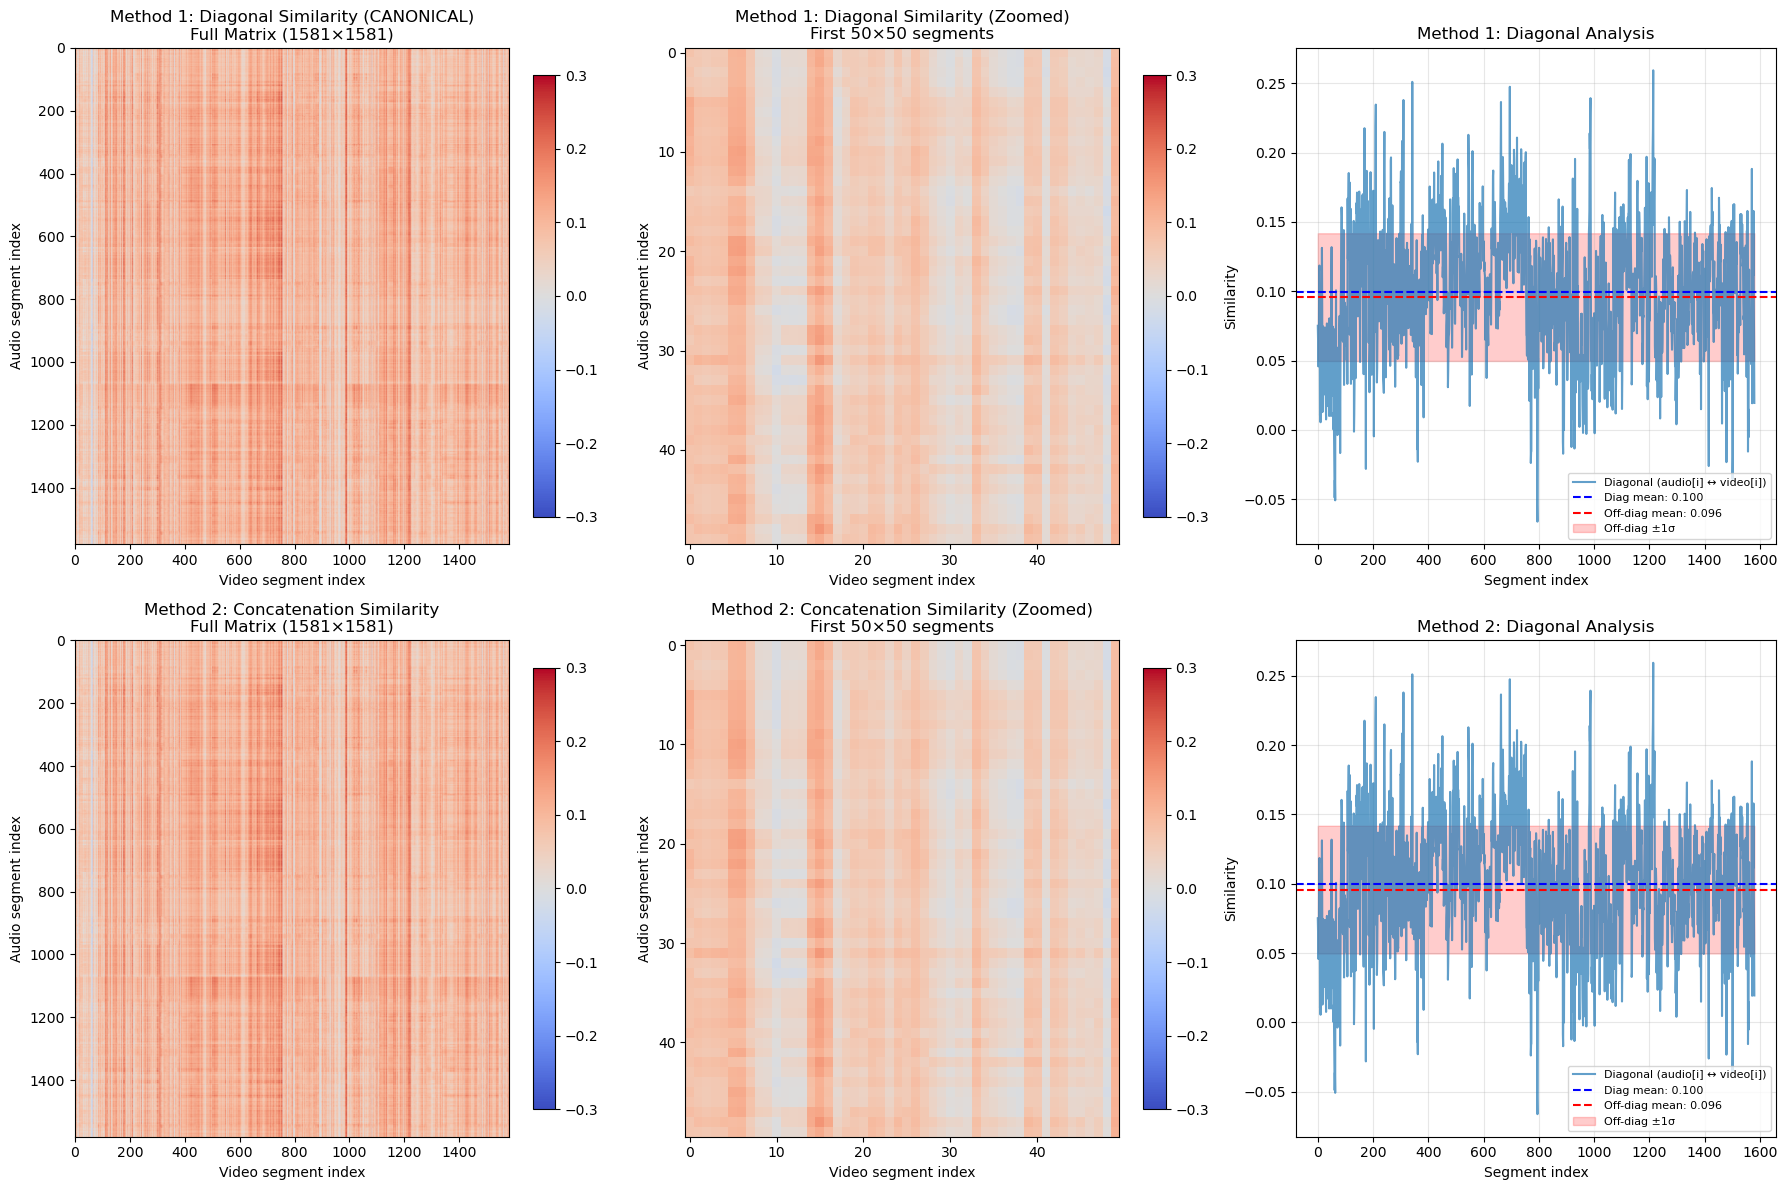


SUMMARY

Method 1 (Diagonal - CANONICAL per paper):
   Accounts for frame-level temporal alignment
   Diagonal advantage: 0.0039

Method 2 (Concatenation):
   Preserves all temporal information in one vector
   Diagonal advantage: 0.0039


In [15]:
# ============================================================================
# Compute Cross-Modal Similarity for CAV-MAE Sync: Two Methods
# 1. Per-frame diagonal similarity (Paper Eq. 5 - CANONICAL)
# 2. Concatenation similarity (Alternative - preserves temporal info)
# ============================================================================
import matplotlib.pyplot as plt

print("="*80)
print("COMPUTING CROSS-MODAL AUDIO-VIDEO SIMILARITY: TWO METHODS")
print("="*80)

# Load per-frame embeddings
audio_perframe = np.load("/home/amin/Research/Representation/Movie/outputs/model_embeddings/cav-mae-sync/2s/embeddings_audio_perframe.npy")
video_perframe = np.load("/home/amin/Research/Representation/Movie/outputs/model_embeddings/cav-mae-sync/2s/embeddings_video_perframe.npy")

num_segments = audio_perframe.shape[0]
num_frames = audio_perframe.shape[1]
embed_dim = audio_perframe.shape[2]

print(f"\nLoaded per-frame embeddings:")
print(f"  Shape: {audio_perframe.shape} = (segments, frames, dim)")
print(f"  {num_segments} segments × {num_frames} frames × {embed_dim} dimensions")

# Helper function
def cosine_matrix(a, b):
    """Compute cosine similarity matrix between rows of a and b"""
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True).clip(min=1e-9)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True).clip(min=1e-9)
    return a_norm @ b_norm.T

# ============================================================================
# METHOD 1: Per-frame diagonal similarity (CANONICAL per paper Eq. 5)
# ============================================================================
print("\n" + "="*80)
print("METHOD 1: Per-Frame Diagonal Similarity (CANONICAL)")
print("="*80)

similarity_diagonal = np.zeros((num_segments, num_segments))

for i in range(num_segments):
    if i % 50 == 0:
        print(f"  Processing segment {i}/{num_segments}...")
    for j in range(num_segments):
        # Get frames for both segments
        audio_frames_i = audio_perframe[i]  # (16, 768)
        video_frames_j = video_perframe[j]  # (16, 768)
        
        # Compute frame-to-frame similarity
        frame_sim = cosine_similarity(audio_frames_i, video_frames_j)  # (16, 16)
        
        # Take diagonal mean (Eq. 5 in paper)
        similarity_diagonal[i, j] = np.diag(frame_sim).mean()

print(f"Computed diagonal similarity matrix: {similarity_diagonal.shape}")

# Compute diagonal statistics
diag_values = np.diag(similarity_diagonal)
off_diag_mask = ~np.eye(num_segments, dtype=bool)
off_diag_values = similarity_diagonal[off_diag_mask]

print(f"\nDiagonal statistics (should be HIGH for good temporal alignment):")
print(f"  Mean diagonal: {diag_values.mean():.4f}")
print(f"  Std diagonal:  {diag_values.std():.4f}")
print(f"  Mean off-diagonal: {off_diag_values.mean():.4f}")
print(f"  Diagonal advantage: {diag_values.mean() - off_diag_values.mean():.4f}")

# ============================================================================
# METHOD 2: Concatenation similarity
# ============================================================================
print("\n" + "="*80)
print("METHOD 2: Concatenation Similarity")
print("="*80)

# Flatten frames for each segment
audio_concat = audio_perframe.reshape(num_segments, -1)  # (230, 12288)
video_concat = video_perframe.reshape(num_segments, -1)  # (230, 12288)

print(f"\nFlattened shapes: {audio_concat.shape}")

# Compute similarity
similarity_concat = cosine_similarity(audio_concat, video_concat)

print(f"Computed concatenation similarity matrix: {similarity_concat.shape}")

# Compute diagonal statistics
diag_values_concat = np.diag(similarity_concat)
off_diag_values_concat = similarity_concat[off_diag_mask]

print(f"\nDiagonal statistics:")
print(f"  Mean diagonal: {diag_values_concat.mean():.4f}")
print(f"  Std diagonal:  {diag_values_concat.std():.4f}")
print(f"  Mean off-diagonal: {off_diag_values_concat.mean():.4f}")
print(f"  Diagonal advantage: {diag_values_concat.mean() - off_diag_values_concat.mean():.4f}")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Diagonal similarity method
# Plot 1a: Full heatmap
vmin, vmax = -0.3, 0.3
im1 = axes[0, 0].imshow(similarity_diagonal, cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
axes[0, 0].set_title(f'Method 1: Diagonal Similarity (CANONICAL)\nFull Matrix ({num_segments}×{num_segments})')
axes[0, 0].set_xlabel('Video segment index')
axes[0, 0].set_ylabel('Audio segment index')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# Plot 1b: Zoomed first 50 segments
zoom_size = min(50, num_segments)
im2 = axes[0, 1].imshow(similarity_diagonal[:zoom_size, :zoom_size], cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
axes[0, 1].set_title(f'Method 1: Diagonal Similarity (Zoomed)\nFirst {zoom_size}×{zoom_size} segments')
axes[0, 1].set_xlabel('Video segment index')
axes[0, 1].set_ylabel('Audio segment index')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# Plot 1c: Diagonal vs off-diagonal
axes[0, 2].plot(diag_values, label='Diagonal (audio[i] ↔ video[i])', linewidth=1.5, alpha=0.7)
axes[0, 2].axhline(diag_values.mean(), color='blue', linestyle='--', 
                   label=f'Diag mean: {diag_values.mean():.3f}')
axes[0, 2].axhline(off_diag_values.mean(), color='red', linestyle='--', 
                   label=f'Off-diag mean: {off_diag_values.mean():.3f}')
axes[0, 2].fill_between(range(len(diag_values)), 
                         off_diag_values.mean() - off_diag_values.std(),
                         off_diag_values.mean() + off_diag_values.std(),
                         alpha=0.2, color='red', label='Off-diag ±1σ')
axes[0, 2].set_title('Method 1: Diagonal Analysis')
axes[0, 2].set_xlabel('Segment index')
axes[0, 2].set_ylabel('Similarity')
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Concatenation similarity method
# Plot 2a: Full heatmap
im3 = axes[1, 0].imshow(similarity_concat, cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
axes[1, 0].set_title(f'Method 2: Concatenation Similarity\nFull Matrix ({num_segments}×{num_segments})')
axes[1, 0].set_xlabel('Video segment index')
axes[1, 0].set_ylabel('Audio segment index')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

# Plot 2b: Zoomed
im4 = axes[1, 1].imshow(similarity_concat[:zoom_size, :zoom_size], cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
axes[1, 1].set_title(f'Method 2: Concatenation Similarity (Zoomed)\nFirst {zoom_size}×{zoom_size} segments')
axes[1, 1].set_xlabel('Video segment index')
axes[1, 1].set_ylabel('Audio segment index')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

# Plot 2c: Diagonal vs off-diagonal
axes[1, 2].plot(diag_values_concat, label='Diagonal (audio[i] ↔ video[i])', linewidth=1.5, alpha=0.7)
axes[1, 2].axhline(diag_values_concat.mean(), color='blue', linestyle='--', 
                   label=f'Diag mean: {diag_values_concat.mean():.3f}')
axes[1, 2].axhline(off_diag_values_concat.mean(), color='red', linestyle='--', 
                   label=f'Off-diag mean: {off_diag_values_concat.mean():.3f}')
axes[1, 2].fill_between(range(len(diag_values_concat)),
                         off_diag_values_concat.mean() - off_diag_values_concat.std(),
                         off_diag_values_concat.mean() + off_diag_values_concat.std(),
                         alpha=0.2, color='red', label='Off-diag ±1σ')
axes[1, 2].set_title('Method 2: Diagonal Analysis')
axes[1, 2].set_xlabel('Segment index')
axes[1, 2].set_ylabel('Similarity')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print("\nMethod 1 (Diagonal - CANONICAL per paper):")
print(f"   Accounts for frame-level temporal alignment")
print(f"   Diagonal advantage: {diag_values.mean() - off_diag_values.mean():.4f}")

print("\nMethod 2 (Concatenation):")
print(f"   Preserves all temporal information in one vector")
print(f"   Diagonal advantage: {diag_values_concat.mean() - off_diag_values_concat.mean():.4f}")



In [12]:
def load_modality_embeddings(emb_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load audio and video and joint embeddings from NPZ file."""
    emb_dir = emb_dir.expanduser().resolve()
    if not emb_dir.exists():
        raise FileNotFoundError(f"Missing embeddings directory: {emb_dir}")
    
    npz_files = list(emb_dir.glob("*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {emb_dir}")
    
    npz_file = npz_files[0]
    print(f"Loading: {npz_file.name}")
    data = np.load(npz_file)
    
    if "audio" not in data or "video" not in data:
        raise KeyError("NPZ must contain 'audio' and 'video' arrays")
    
    audio = data["audio"]
    video = data["video"]
    try:
        joint = data["joint"]
    except:
        joint = np.array([]) 
    if audio.shape[0] != video.shape[0]:
        raise ValueError(
            f"Segment count mismatch: audio={audio.shape[0]} video={video.shape[0]}"
        )
    
    print(f"  Audio shape: {audio.shape}, Video shape: {video.shape}, joint shape: {audio.shape}")
    return audio, video, joint

def compute_av_similarity(audio: np.ndarray, video: np.ndarray) -> np.ndarray:
    """Compute cosine similarity matrix between audio and video embeddings using sklearn."""
    sim = cosine_similarity(audio, video)
    return sim


def plot_av_similarity_heatmap(
    sim: np.ndarray,
    out_path: Path,
    title: str,
    vmin: float = None,
    vmax: float = None,
    figsize: Tuple[int, int] = (6, 5),
) -> None:
    """Plot audio-video cross-similarity heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    
    if vmin is None:
        vmin = np.nanmin(sim)
    if vmax is None:
        vmax = np.nanmax(sim)
    
    im = ax.imshow(sim, origin="upper", cmap="coolwarm", vmin=vmin, vmax=vmax)
    
    cbar = fig.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("Cosine similarity", fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Video segment index", fontsize=10)
    ax.set_ylabel("Audio segment index", fontsize=10)
    
    fig.tight_layout()
    if out_path is not None:
        out_path = out_path.expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {out_path}")
    plt.show()
    plt.close(fig)

COMPARING JOINT vs SINGLE MODALITY ENCODINGS

[1] Loading joint encoding embeddings...
Loading: pe-av-small-16-frame_2s.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

[2] Loading single encoding embeddings...
Loading: pe-av-small-16-frame_2s.npz
  Audio shape: (1581, 1024), Video shape: (1581, 1024), joint shape: (1581, 1024)

[3] Computing audio-video similarity matrices...

Joint encoding similarity: shape=(1581, 1581), mean=0.023, std=0.038
Single encoding similarity: shape=(1581, 1581), mean=0.023, std=0.038

[4] Plotting joint encoding similarity...


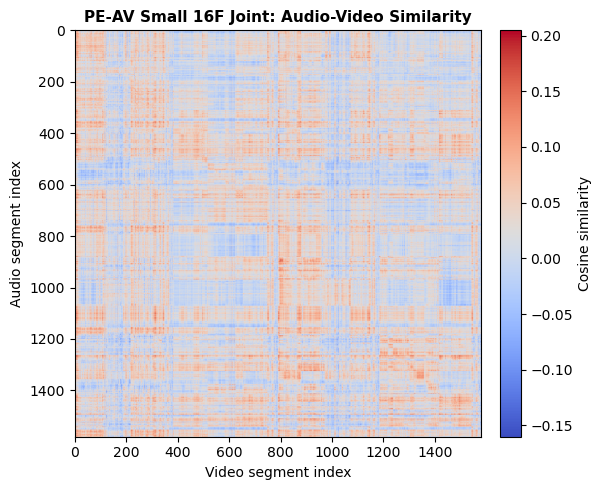


[5] Plotting single encoding similarity...


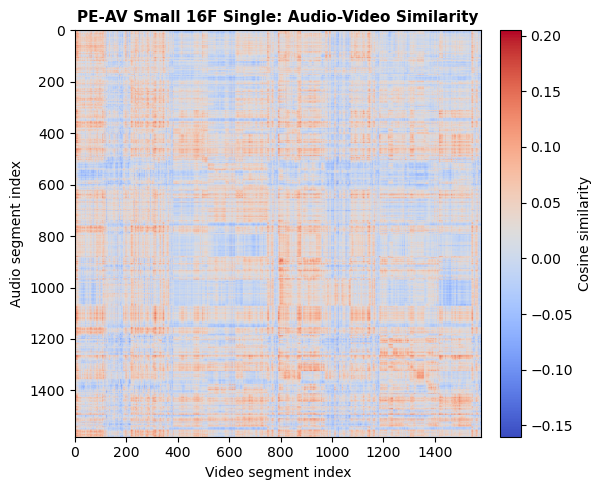


[6] Computing RSA between joint and single encodings...

RSA RESULTS: Joint vs Single Encoding
Spearman correlation (RSA): 1.0000 (p = 0.00e+00)
Pearson correlation:        1.0000
Number of compared pairs:   1,248,990


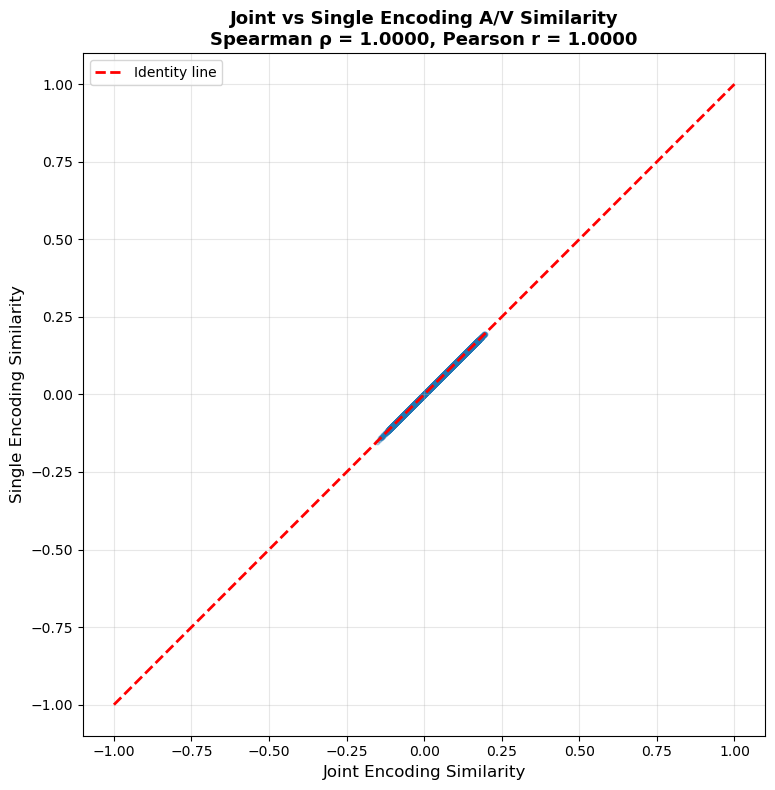

In [17]:
# Define paths for joint and single encoding
joint_config = {
    "label": "pe-av-small-16-frame-joint",
    "model_name": "PE-AV Small 16F Joint",
    "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame"),
}

single_config = {
    "label": "pe-av-small-16-frame-single",
    "model_name": "PE-AV Small 16F Single",
    "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/pe-av-small-16-frame-single-modality"),
}

print("="*70)
print("COMPARING JOINT vs SINGLE MODALITY ENCODINGS")
print("="*70)

# Load joint encoding embeddings
print("\n[1] Loading joint encoding embeddings...")
audio_joint, video_joint, _ = load_modality_embeddings(joint_config["emb_dir"])

# Load single encoding embeddings
print("\n[2] Loading single encoding embeddings...")
audio_single, video_single, _ = load_modality_embeddings(single_config["emb_dir"])

# Compute similarity matrices
print("\n[3] Computing audio-video similarity matrices...")
sim_joint = compute_av_similarity(audio_joint, video_joint)
sim_single = compute_av_similarity(audio_single, video_single)

print(f"\nJoint encoding similarity: shape={sim_joint.shape}, "
      f"mean={sim_joint.mean():.3f}, std={sim_joint.std():.3f}")
print(f"Single encoding similarity: shape={sim_single.shape}, "
      f"mean={sim_single.mean():.3f}, std={sim_single.std():.3f}")

# Create output directory for comparison
comparison_dir = Path("/home/amin/Research/Representation/Movie/outputs/model_embeddings/pe-av-small-16-frame/joint_vs_single_comparison")
comparison_dir.mkdir(parents=True, exist_ok=True)

# Plot joint encoding similarity
print("\n[4] Plotting joint encoding similarity...")

plot_av_similarity_heatmap(
    sim_joint,
    None,
    f"{joint_config['model_name']}: Audio-Video Similarity",
)

# Plot single encoding similarity
print("\n[5] Plotting single encoding similarity...")

plot_av_similarity_heatmap(
    sim_single,
    None,
    f"{single_config['model_name']}: Audio-Video Similarity",
)

# Compute RSA (Representational Similarity Analysis) between the two similarity matrices
print("\n[6] Computing RSA between joint and single encodings...")

# Flatten the upper triangle of both matrices (excluding diagonal)
mask = np.triu(np.ones_like(sim_joint, dtype=bool), k=1)
sim_joint_flat = sim_joint[mask]
sim_single_flat = sim_single[mask]

# Compute Spearman correlation (RSA)
rsa_corr, rsa_pval = stats.spearmanr(sim_joint_flat, sim_single_flat)

# Also compute Pearson correlation for comparison
pearson_corr = np.corrcoef(sim_joint_flat, sim_single_flat)[0, 1]

print("\n" + "="*70)
print("RSA RESULTS: Joint vs Single Encoding")
print("="*70)
print(f"Spearman correlation (RSA): {rsa_corr:.4f} (p = {rsa_pval:.2e})")
print(f"Pearson correlation:        {pearson_corr:.4f}")
print(f"Number of compared pairs:   {len(sim_joint_flat):,}")
print("="*70)

# Create scatter plot comparing the two similarity matrices
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(sim_joint_flat, sim_single_flat, alpha=0.3, s=10)
ax.plot([-1, 1], [-1, 1], 'r--', linewidth=2, label='Identity line')

ax.set_xlabel('Joint Encoding Similarity', fontsize=12)
ax.set_ylabel('Single Encoding Similarity', fontsize=12)
ax.set_title(f'Joint vs Single Encoding A/V Similarity\n'
             f'Spearman ρ = {rsa_corr:.4f}, Pearson r = {pearson_corr:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()
plt.close(fig)